In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

In [2]:
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

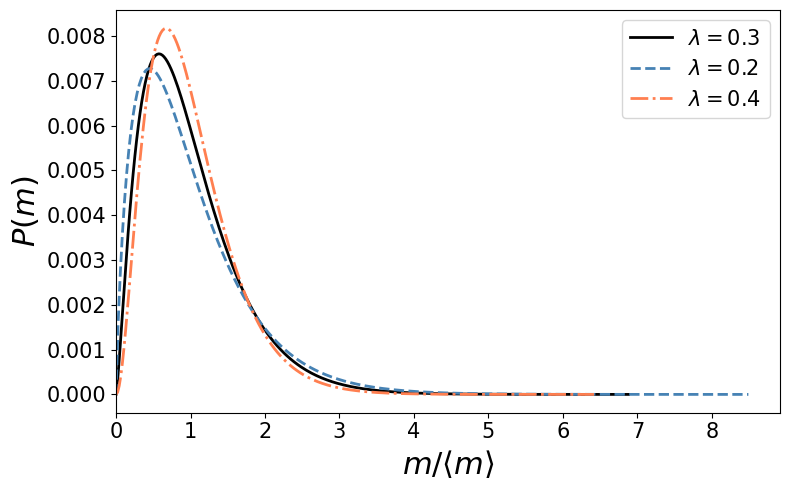

In [3]:
from scipy.stats import gamma
import numpy as np
import matplotlib.pyplot as plt

M = 5e4
N = 500

lambdas  = [0.3,0.2,0.4]
colors   = ['black', 'steelblue', 'coral', 'seagreen', 'mediumpurple']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")

for lamb, color, ls in zip(lambdas, colors, linestyles):
    data = np.load(f'Pm_lamb{lamb:.1f}.npy') / (M/N)
    data_flat = data.flatten()
    
    alpha, loc, scale = gamma.fit(data_flat, floc=0)
    
    x_fit = np.linspace(0, data.max(), 300)
    y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)
    
    ax.plot(x_fit, y_fit/100, color=color, lw=2, linestyle=ls,
            label=fr'$\lambda={lamb:.1f}$')

ax.set_xlim(left=0)
ax.set_xlabel(r'$m/\langle m \rangle$', fontsize=22)
ax.set_ylabel(r'$P(m)$', fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

ax.legend(fontsize=15)
plt.tight_layout()
plt.savefig('WS_Full.pdf', bbox_inches='tight')
plt.show()

In [5]:
import numpy as np

M = 5e4
N = 500

lambdas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

#-----------------------------------INDICES--------------------------------------

def gini(x):
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * x) / (n * np.sum(x))) - (n + 1) / n

def theil_normalizado(x):
    x = x[x > 0]
    n = len(x)
    mu = x.mean()
    T = np.sum((x / mu) * np.log(x / mu)) / n
    T_max = np.log(n)
    return T / T_max

#-----------------------------------CALCULO--------------------------------------

print(f"{'λ':<6} {'Gini':>10} {'Theil norm.':>14}")
print("-" * 32)

for lamb in lambdas:
    data = np.load(f'Pm_lamb{lamb:.1f}.npy') / (M/N)
    data_flat = data.flatten()

    g = gini(data_flat)
    t = theil_normalizado(data_flat)
    print(f"{lamb:<6.1f} {g:>10.4f} {t:>14.4f}")

λ            Gini    Theil norm.
--------------------------------
0.0        0.5002         0.0322
0.1        0.4448         0.0250
0.2        0.3972         0.0196
0.3        0.3529         0.0153
0.4        0.3121         0.0119
0.5        0.2734         0.0091
0.6        0.2351         0.0067
0.7        0.1963         0.0047
0.8        0.1549         0.0029
0.9        0.1060         0.0013
